# Parrondo Parameter Sensitivity Analysis

This notebook summarizes how the parameter search was designed and which
parameter settings were associated with Parrondo-type outcomes.

The search was **not a full factorial search**. It evaluated 2,400 unique
combinations sampled from the full discrete search space. The analysis below
uses those completed simulations and does not rerun the cellular automaton.

In [1]:
from pathlib import Path
import os

current_path = Path.cwd().resolve()
repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "scripts").is_dir()
)
os.chdir(repo_root)

print(f"Repository root: {repo_root}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_path = repo_root / "results" / "strong_parrondo_equal_budget_search.csv"
search_results = pd.read_csv(results_path)

parameter_columns = [
    "a_rate",
    "b_rate",
    "max_cells",
    "boundary",
    "b_lower",
    "growth_rate",
    "diffusion_rate",
    "budget",
]

# Strict means that both AB and BA improve while A and B alone worsen.
search_results["strict_parrondo"] = (
    search_results["ab_parrondo"]
    & search_results["ba_parrondo"]
)

search_results.head()

,sample_id,a_rate,b_rate,max_cells,boundary,b_lower,growth_rate,diffusion_rate,budget,a_relative_change,...,ba_final_mean,ba_cost,ba_cumulative_weed,ba_high_density_cells,ab_margin,ba_margin,best_margin,ab_parrondo,ba_parrondo,strict_parrondo
0,256,0.25,0.50,150,0.55,0.25,0.020,0.0100,450000,0.029815,...,0.838184,450000.000000,81.440004,6155,0.024480,0.026018,0.026018,True,True,True
1,466,0.30,0.80,100,0.65,0.25,0.035,0.0050,450000,0.086785,...,0.834568,450000.000000,82.786579,6039,0.022643,0.022643,0.022643,True,True,True
2,972,0.30,0.45,100,0.55,0.05,0.015,0.0100,350000,0.021394,...,0.838871,350000.000000,82.075955,6190,0.021394,0.021394,0.021394,True,True,True
3,277,0.35,0.45,100,0.60,0.15,0.020,0.0025,350000,0.034857,...,0.821629,350000.000000,80.149965,6109,0.020427,0.020427,0.020427,True,True,True
4,1304,0.15,0.50,150,0.60,0.10,0.035,0.0025,400000,0.068350,...,0.843004,337675.105286,84.381676,6128,0.017312,0.020418,0.020418,True,True,True


## 1. Search-space design

Eight parameters were varied. The table below reports the exact discrete
levels represented in the search results.

The complete Cartesian product contains every possible combination of these
levels. Only 2,400 unique combinations were evaluated, so this is a broad
random sample rather than an exhaustive search.

In [3]:
search_space_rows = []

for parameter in parameter_columns:
    values = np.sort(search_results[parameter].unique())
    search_space_rows.append(
        {
            "parameter": parameter,
            "number_of_levels": len(values),
            "levels": ", ".join(f"{value:g}" for value in values),
        }
    )

search_space = pd.DataFrame(search_space_rows)
search_space

,parameter,number_of_levels,levels
0,a_rate,10,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
1,b_rate,15,"0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0...."
2,max_cells,7,"25, 50, 75, 100, 150, 200, 300"
3,boundary,8,"0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9"
4,b_lower,10,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
5,growth_rate,7,"0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04"
6,diffusion_rate,6,"0.0025, 0.005, 0.01, 0.015, 0.02, 0.03"
7,budget,7,"150000, 200000, 250000, 300000, 350000, 400000..."


In [4]:
full_factorial_size = int(
    np.prod(search_space["number_of_levels"])
)
evaluated_conditions = len(search_results)
unique_conditions = len(
    search_results.drop_duplicates(parameter_columns)
)
sampling_fraction = evaluated_conditions / full_factorial_size

search_overview = pd.Series(
    {
        "full_factorial_combinations": full_factorial_size,
        "evaluated_conditions": evaluated_conditions,
        "unique_evaluated_conditions": unique_conditions,
        "sampling_fraction": sampling_fraction,
        "sampling_percentage": 100 * sampling_fraction,
        "strict_parrondo_conditions": int(
            search_results["strict_parrondo"].sum()
        ),
    },
    name="value",
)

search_overview

full_factorial_combinations    2.469600e+07
evaluated_conditions           2.400000e+03
unique_evaluated_conditions    2.400000e+03
sampling_fraction              9.718173e-05
sampling_percentage            9.718173e-03
strict_parrondo_conditions     5.100000e+01
Name: value, dtype: float64

## 2. Sampling balance

Because the search used a subset of the full space, first check whether each
parameter level was represented reasonably evenly. Large imbalances would
make raw Parrondo counts misleading.

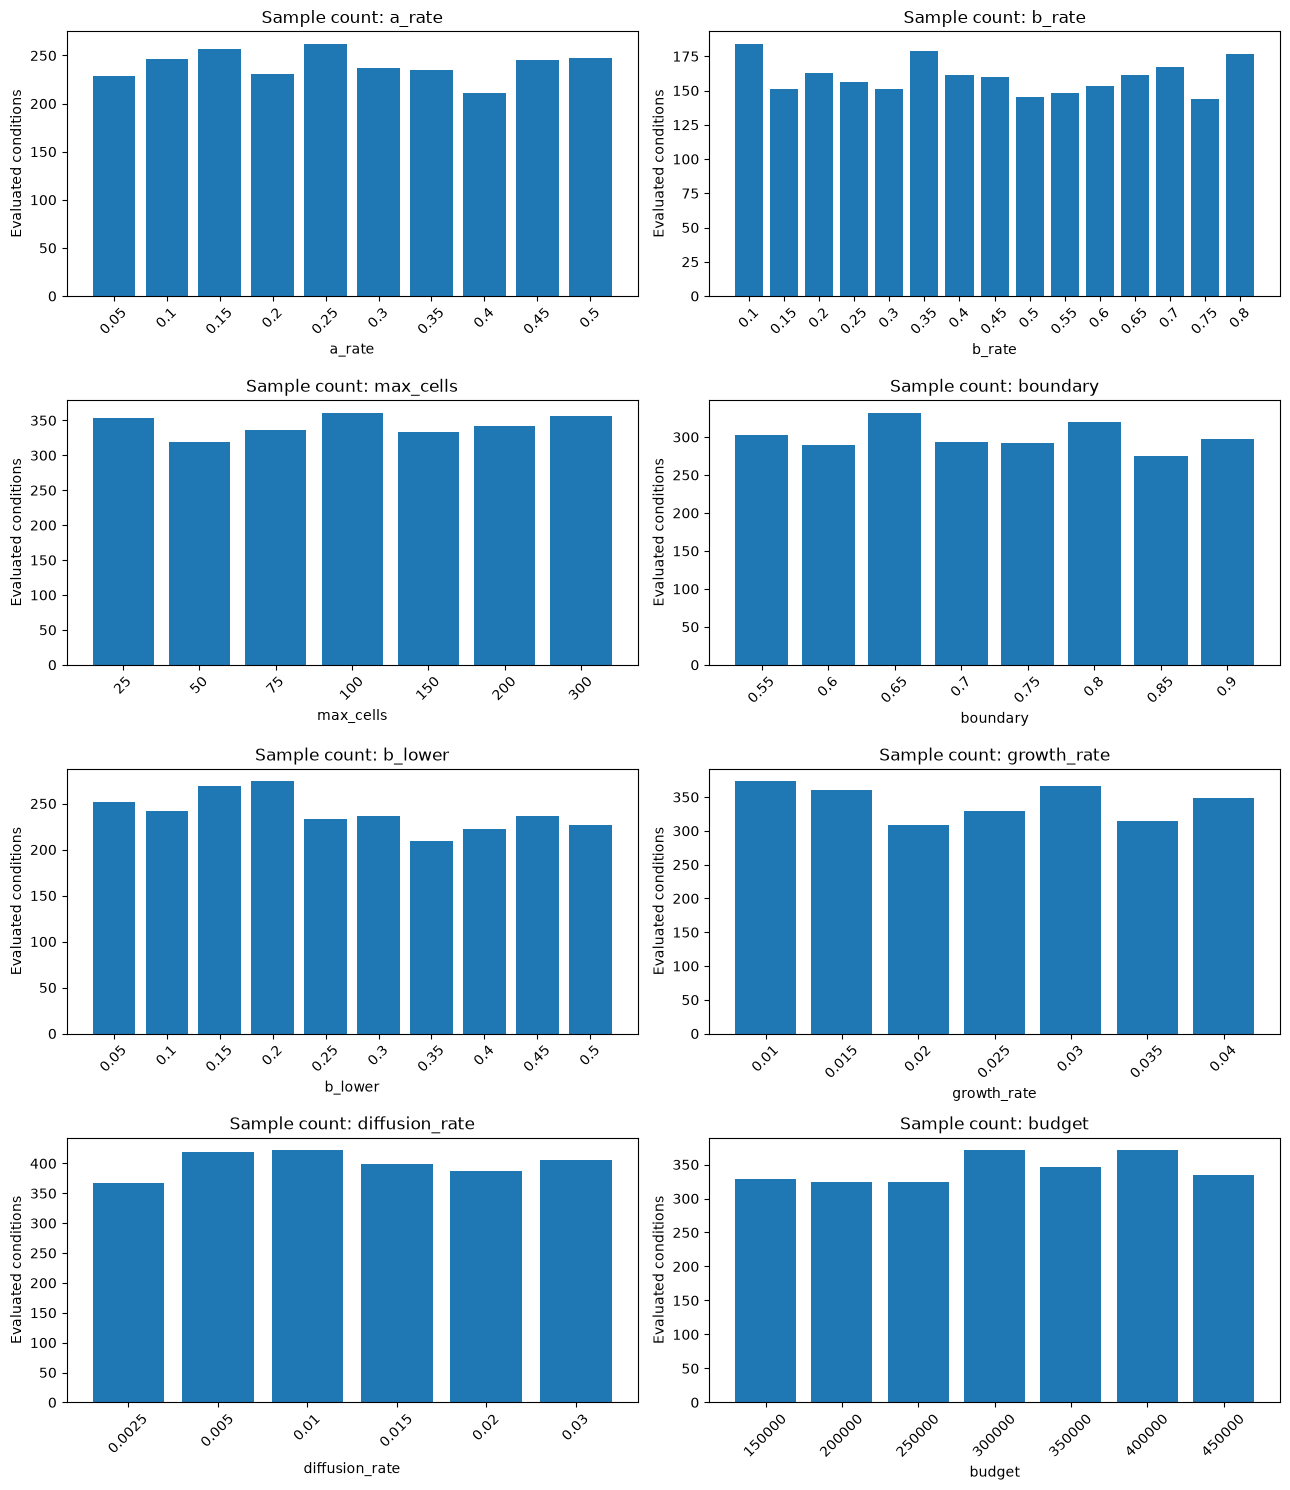

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(13, 15))

for ax, parameter in zip(axes.flat, parameter_columns):
    counts = search_results[parameter].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"Sample count: {parameter}")
    ax.set_xlabel(parameter)
    ax.set_ylabel("Evaluated conditions")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3. One-parameter sensitivity

For each level, calculate the proportion of sampled conditions satisfying the
strict Parrondo definition. A percentage is more informative than a raw count
because the number of sampled conditions can differ slightly between levels.

These are **marginal rates**: all other parameters are mixed together. They
show association, not an isolated causal effect.

In [6]:
sensitivity_tables = {}

for parameter in parameter_columns:
    table = (
        search_results.groupby(parameter, as_index=False)
        .agg(
            evaluated=("strict_parrondo", "size"),
            strict_parrondo_count=("strict_parrondo", "sum"),
            strict_parrondo_rate=("strict_parrondo", "mean"),
            mean_best_margin=("best_margin", "mean"),
        )
    )
    table["strict_parrondo_percent"] = (
        100 * table["strict_parrondo_rate"]
    )
    sensitivity_tables[parameter] = table

sensitivity_tables["diffusion_rate"]

,diffusion_rate,evaluated,strict_parrondo_count,strict_parrondo_rate,mean_best_margin,strict_parrondo_percent
0,0.0025,367,25,0.068120,-0.067987,6.811989
1,0.0050,419,14,0.033413,-0.070519,3.341289
2,0.0100,422,9,0.021327,-0.080962,2.132701
3,0.0150,399,2,0.005013,-0.093688,0.501253
4,0.0200,388,1,0.002577,-0.102081,0.257732
5,0.0300,405,0,0.000000,-0.123437,0.000000


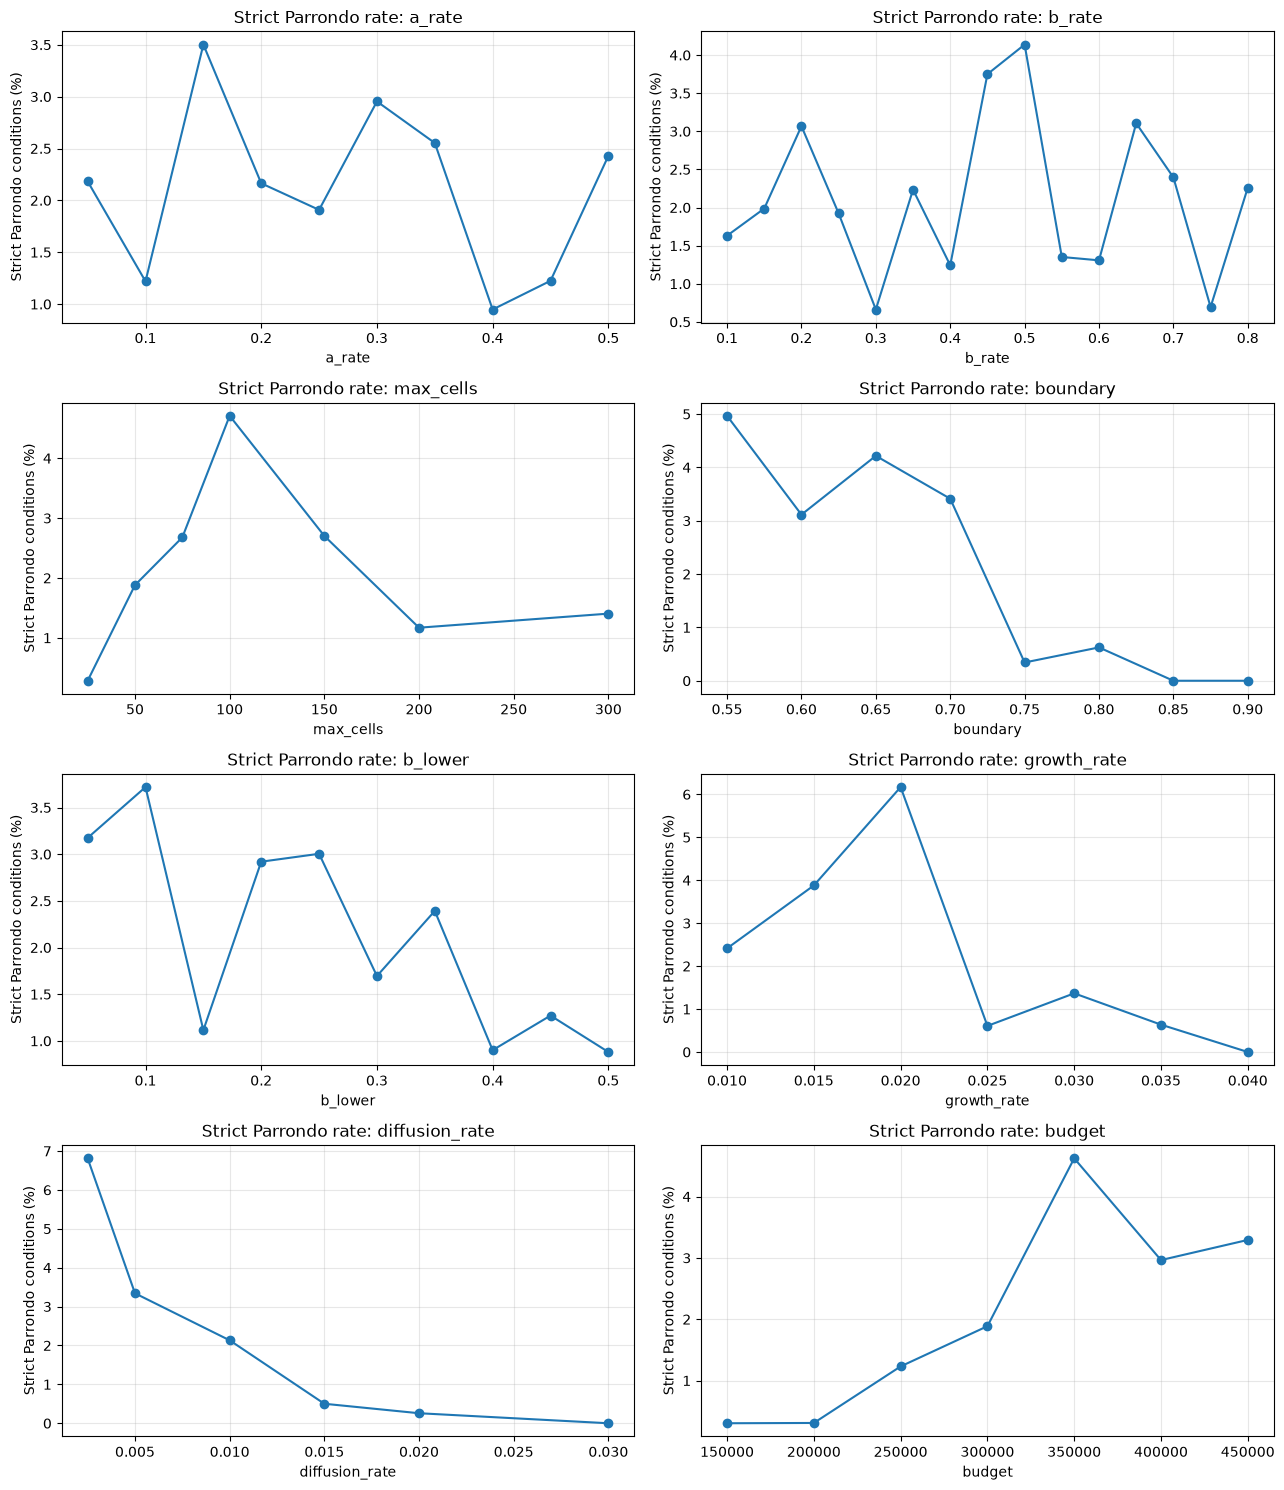

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(13, 15))

for ax, parameter in zip(axes.flat, parameter_columns):
    table = sensitivity_tables[parameter]
    ax.plot(
        table[parameter],
        table["strict_parrondo_percent"],
        marker="o",
    )
    ax.set_title(f"Strict Parrondo rate: {parameter}")
    ax.set_xlabel(parameter)
    ax.set_ylabel("Strict Parrondo conditions (%)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Rank parameters by marginal variation

The table below ranks parameters by the range between their highest and
lowest observed strict-Parrondo rates. A larger range means that the outcome
changed more strongly across the tested levels.

This is a descriptive sensitivity score, not a formal variance decomposition.

In [8]:
parameter_ranking_rows = []

for parameter, table in sensitivity_tables.items():
    rates = table["strict_parrondo_percent"]
    best_row = table.loc[rates.idxmax()]
    worst_row = table.loc[rates.idxmin()]

    parameter_ranking_rows.append(
        {
            "parameter": parameter,
            "rate_range_percentage_points": rates.max() - rates.min(),
            "best_level": best_row[parameter],
            "best_rate_percent": best_row["strict_parrondo_percent"],
            "worst_level": worst_row[parameter],
            "worst_rate_percent": worst_row["strict_parrondo_percent"],
        }
    )

parameter_ranking = (
    pd.DataFrame(parameter_ranking_rows)
    .sort_values("rate_range_percentage_points", ascending=False)
    .reset_index(drop=True)
)

parameter_ranking

,parameter,rate_range_percentage_points,best_level,best_rate_percent,worst_level,worst_rate_percent
0,diffusion_rate,6.811989,0.0025,6.811989,0.03,0.000000
1,growth_rate,6.168831,0.0200,6.168831,0.04,0.000000
2,boundary,4.966887,0.5500,4.966887,0.85,0.000000
3,max_cells,4.425855,100.0000,4.709141,25.00,0.283286
4,budget,4.320326,350000.0000,4.624277,150000.00,0.303951
5,b_rate,3.475679,0.5000,4.137931,0.30,0.662252
6,b_lower,2.837951,0.1000,3.719008,0.50,0.881057
7,a_rate,2.554078,0.1500,3.501946,0.40,0.947867


## 5. Two-parameter combinations

Parrondo-type behaviour is produced by interactions, so one-parameter plots
are not sufficient. The following heatmaps show strict-Parrondo rates for
three interpretable pairs:

- growth rate × diffusion rate;
- boundary × maximum treated cells;
- Policy A removal rate × Policy B removal rate.

Blank cells indicate that the sampled search did not include that pair.

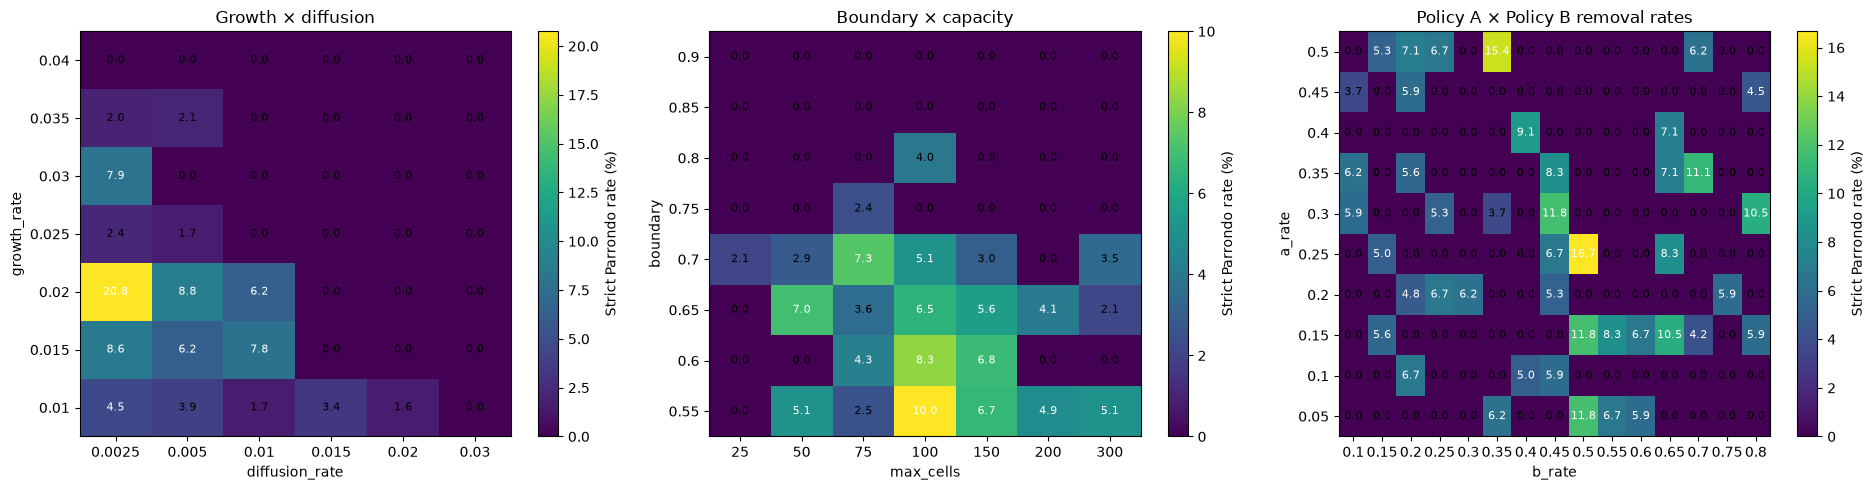

In [9]:
def parrondo_rate_pivot(row_parameter, column_parameter):
    return search_results.pivot_table(
        index=row_parameter,
        columns=column_parameter,
        values="strict_parrondo",
        aggfunc="mean",
    ) * 100


def plot_rate_heatmap(ax, pivot, title):
    image = ax.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0,
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{value:g}" for value in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{value:g}" for value in pivot.index])
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)
    ax.set_title(title)

    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            value = pivot.iloc[row, column]
            if pd.notna(value):
                ax.text(
                    column,
                    row,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    color="white" if value > 4 else "black",
                    fontsize=8,
                )

    return image


pairs = [
    ("growth_rate", "diffusion_rate", "Growth × diffusion"),
    ("boundary", "max_cells", "Boundary × capacity"),
    ("a_rate", "b_rate", "Policy A × Policy B removal rates"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, (row_parameter, column_parameter, title) in zip(axes, pairs):
    pivot = parrondo_rate_pivot(row_parameter, column_parameter)
    image = plot_rate_heatmap(ax, pivot, title)
    fig.colorbar(image, ax=ax, label="Strict Parrondo rate (%)")

plt.tight_layout()
plt.show()

## 6. Strong and clean candidates

The initial 2,400-condition screen only checks A, B, AB, and BA. The strongest
raw effect is not necessarily the cleanest scheduling effect.

Block controls and random-order controls were therefore applied later to the
leading candidates. Load those results and compare them with the condition
selected for the validation notebook.

In [10]:
validated_path = repo_root / "results" / "strong_parrondo_block_validated.csv"
finalists_path = repo_root / "results" / "strong_parrondo_finalists.csv"

block_validated = pd.read_csv(validated_path)
finalists = pd.read_csv(finalists_path)

clean_candidates = block_validated[
    block_validated["blocks_losing"]
].sort_values("clean_margin", ascending=False)

selected_candidates = finalists[
    (finalists["clean_margin"] > 0)
    & (finalists["random_winning_fraction"] < 0.5)
].sort_values("clean_margin", ascending=False)

validation_overview = pd.Series(
    {
        "initial_conditions": len(search_results),
        "strict_AB_and_BA_candidates": int(
            search_results["strict_parrondo"].sum()
        ),
        "block_validated_conditions": len(block_validated),
        "conditions_with_both_blocks_losing": int(
            block_validated["blocks_losing"].sum()
        ),
        "finalists_with_random_validation": len(finalists),
        "clean_finalists_with_random_win_rate_below_50_percent": len(
            selected_candidates
        ),
    },
    name="count",
)

validation_overview

initial_conditions                                       2400
strict_AB_and_BA_candidates                                51
block_validated_conditions                                100
conditions_with_both_blocks_losing                         23
finalists_with_random_validation                          100
clean_finalists_with_random_win_rate_below_50_percent       2
Name: count, dtype: int64

In [11]:
display_columns = [
    "sample_id",
    "clean_margin",
    "random_winning_fraction",
    "a_rate",
    "b_rate",
    "max_cells",
    "boundary",
    "b_lower",
    "growth_rate",
    "diffusion_rate",
    "budget",
]

selected_candidates[display_columns].head(10)

,sample_id,clean_margin,random_winning_fraction,a_rate,b_rate,max_cells,boundary,b_lower,growth_rate,diffusion_rate,budget
5,2036,0.003486,0.45,0.15,0.65,50,0.7,0.45,0.010,0.0100,250000
8,1370,0.002420,0.45,0.05,0.55,75,0.7,0.40,0.015,0.0025,350000


## Interpretation and limitations

The marginal analysis indicates where Parrondo-type conditions appeared most
often in this sample. In particular, low diffusion, an intermediate growth
rate, moderate treatment capacity, and a boundary below the highest tested
values were associated with more strict outcomes.

Important limitations:

1. Only 2,400 of the full combinations were evaluated.
2. Some parameter interactions may be missed by the random sample.
3. Marginal rates mix together the effects of the other seven parameters.
4. The later block and random-order checks were applied only to selected
   candidates, not to all 2,400 conditions.
5. A larger or targeted follow-up search is required for formal global
   sensitivity analysis.

Therefore, this notebook should be interpreted as an empirical screening
analysis rather than a complete Sobol-style sensitivity analysis.